# Portfolio Analysis
Analysis of ISA and SIPP portfolio values from the HL investment dashboard.

In [2]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

con = duckdb.connect('data/hl_dashboard.duckdb', read_only=True)

## Portfolio Value Over Time

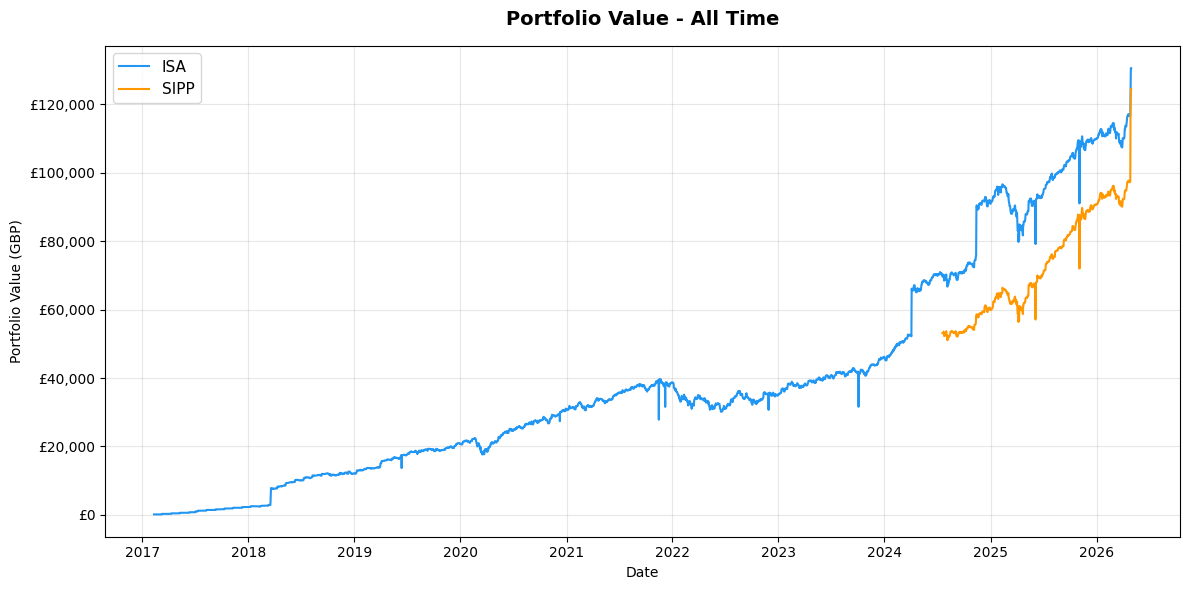

In [3]:
df = con.execute(
    'SELECT date, account_id, portfolio_value_gbp FROM mart_daily_portfolio_value ORDER BY date'
).fetchdf()

isa = df[df['account_id'] == 'ISA'].set_index('date')['portfolio_value_gbp']
sipp = df[df['account_id'] == 'SIPP'].set_index('date')['portfolio_value_gbp']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(isa.index, isa.values, label='ISA', linewidth=1.5, color='#2196F3')
ax.plot(sipp.index, sipp.values, label='SIPP', linewidth=1.5, color='#FF9800')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Portfolio Value - All Time', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (GBP)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

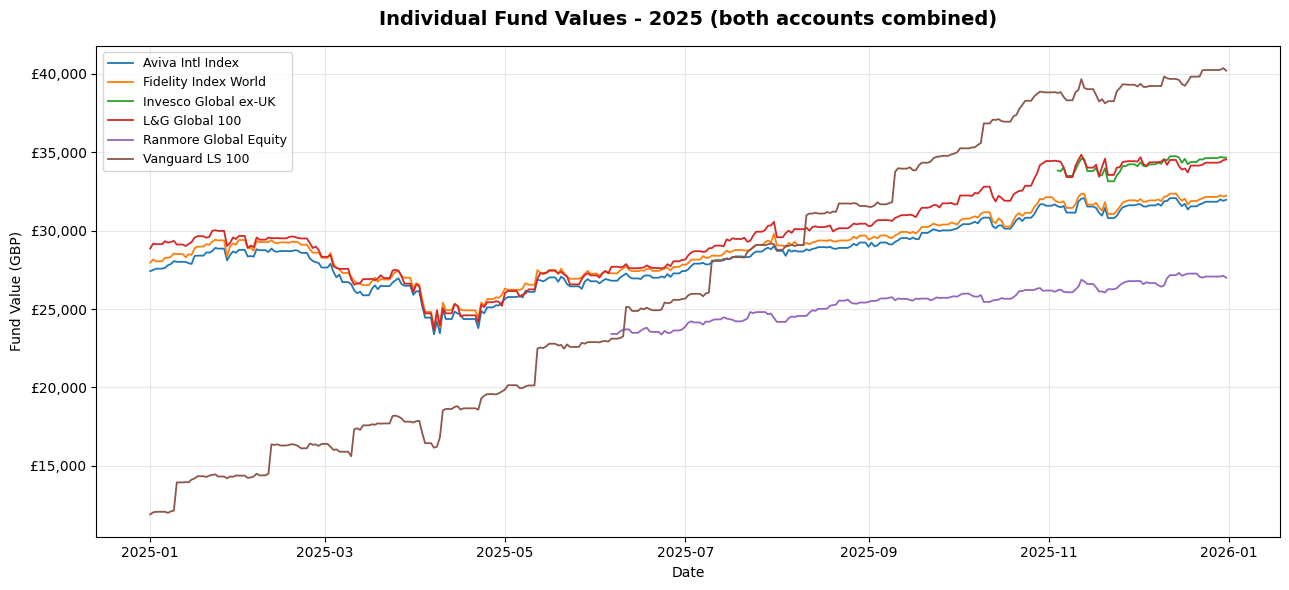

In [5]:
funds_end_2025 = con.execute("""
    SELECT DISTINCT fund_id
    FROM int_daily_fund_values
    WHERE date = (SELECT MAX(date) FROM int_daily_fund_values WHERE date <= '2025-12-31')
      AND value_gbp > 1
""").fetchdf()['fund_id'].tolist()

fund_values = con.execute(f"""
    SELECT date, fund_name, SUM(value_gbp) AS value_gbp
    FROM int_daily_fund_values
    WHERE date BETWEEN '2025-01-01' AND '2025-12-31'
      AND fund_id IN ({','.join(f"'{f}'" for f in funds_end_2025)})
    GROUP BY date, fund_id, fund_name
    ORDER BY date
""").fetchdf()

short_names = {
    'Legal & General Global 100 Index Class C - Accumulation': 'L&G Global 100',
    'Fidelity Index World Class P - Accumulation': 'Fidelity Index World',
    'Vanguard LifeStrategy 100% Equity Accumulation': 'Vanguard LS 100',
    'Aviva Investors International Index Tracking Class 2 - Accumulation': 'Aviva Intl Index',
    'Invesco Global ex-UK Enhanced Index Class Z - Accumulation': 'Invesco Global ex-UK',
    'Ranmore Global Equity Investor - Accumulation': 'Ranmore Global Equity',
}
fund_values['label'] = fund_values['fund_name'].map(short_names).fillna(fund_values['fund_name'])

fig, ax = plt.subplots(figsize=(13, 6))
for label, grp in fund_values.groupby('label'):
    ax.plot(grp['date'], grp['value_gbp'], label=label, linewidth=1.3)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Individual Fund Values - 2025 (both accounts combined)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Fund Value (GBP)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

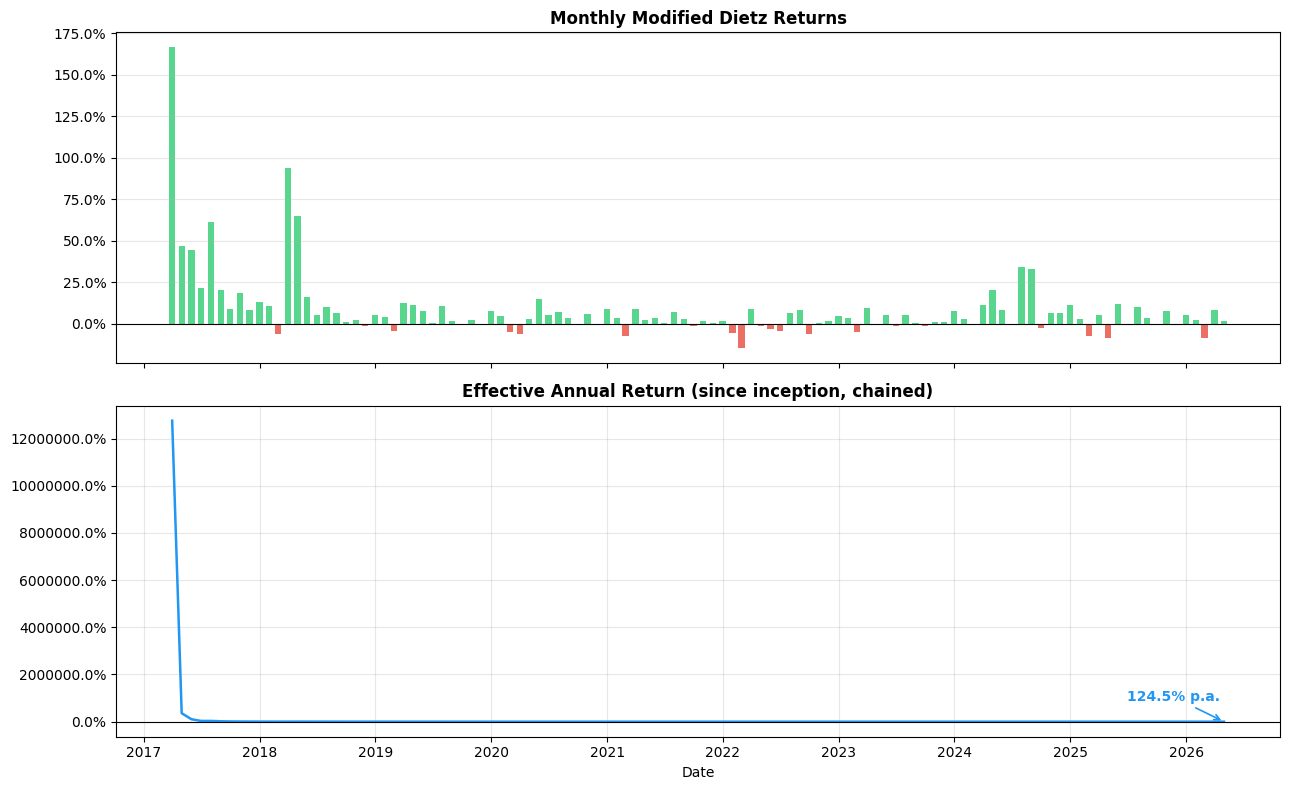

In [6]:
import numpy as np

# --- Month-end portfolio values (both accounts combined) ---
monthly = con.execute("""
    SELECT LAST_DAY(date) AS date, SUM(portfolio_value_gbp) AS portfolio_value_gbp
    FROM mart_daily_portfolio_value
    GROUP BY LAST_DAY(date)
    ORDER BY 1
""").fetchdf()
monthly['date'] = pd.to_datetime(monthly['date'])
monthly = monthly.set_index('date')

# --- Contribution events (both accounts combined) ---
contribs = con.execute("""
    SELECT trade_date AS date, SUM(value_gbp) AS contribution_gbp
    FROM stg_transactions
    WHERE is_contribution
    GROUP BY trade_date
    ORDER BY trade_date
""").fetchdf()
contribs['date'] = pd.to_datetime(contribs['date'])

# --- Modified Dietz return for each month ---
# R = (V_end - V_start - C) / (V_start + weighted_C)
# where each contribution is weighted by (days remaining in month) / (total days in month)
dates = monthly.index.tolist()
monthly_returns = []
return_dates = []

for i in range(1, len(dates)):
    month_end   = dates[i]
    month_start = dates[i - 1]
    v_start     = monthly.loc[month_start, 'portfolio_value_gbp']
    v_end       = monthly.loc[month_end,   'portfolio_value_gbp']

    mask = (contribs['date'] > month_start) & (contribs['date'] <= month_end)
    mc = contribs[mask].copy()

    d_total = (month_end - month_start).days
    if d_total == 0 or v_start <= 0:
        continue

    mc['weight'] = mc['date'].apply(lambda d: (month_end - d).days / d_total)
    C  = mc['contribution_gbp'].sum()
    WC = (mc['contribution_gbp'] * mc['weight']).sum()

    denominator = v_start + WC
    if denominator <= 0:
        continue

    monthly_returns.append((v_end - v_start - C) / denominator)
    return_dates.append(month_end)

returns_s = pd.Series(monthly_returns, index=pd.DatetimeIndex(return_dates))

# --- Rolling annualised return (since inception, chained geometrically) ---
def annualise(returns):
    n = len(returns)
    return np.prod([1 + r for r in returns]) ** (12 / n) - 1

rolling_annual = pd.Series(
    {d: annualise(returns_s.loc[:d]) for d in return_dates},
    dtype=float
)

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

colours = ['#2ecc71' if r >= 0 else '#e74c3c' for r in monthly_returns]
axes[0].bar(return_dates, [r * 100 for r in monthly_returns], color=colours, width=20, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[0].set_title('Monthly Modified Dietz Returns', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(rolling_annual.index, rolling_annual.values * 100, color='#2196F3', linewidth=1.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[1].set_title('Effective Annual Return (since inception, chained)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

current_annual = rolling_annual.iloc[-1] * 100
axes[1].annotate(
    f'{current_annual:.1f}% p.a.',
    xy=(rolling_annual.index[-1], rolling_annual.iloc[-1]),
    xytext=(-70, 15), textcoords='offset points',
    fontsize=10, fontweight='bold', color='#2196F3',
    arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.2),
)

fig.tight_layout()
plt.show()

## Contributions per Account per Month

In [ ]:
contribs_fy = con.execute("""
    SELECT
        dd.financial_year,
        c.account_id,
        SUM(c.contributed_today) AS contribution_gbp
    FROM int_daily_contributions c
    JOIN dim_date dd ON dd.date = c.date
    WHERE c.contributed_today > 0
    GROUP BY dd.financial_year, c.account_id
    ORDER BY dd.financial_year, c.account_id
""").fetchdf()

pivot = contribs_fy.pivot(index='financial_year', columns='account_id', values='contribution_gbp').fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(pivot))
width = 0.4
isa_vals  = pivot.get('ISA',  pd.Series(0, index=pivot.index))
sipp_vals = pivot.get('SIPP', pd.Series(0, index=pivot.index))

ax.bar([i - width/2 for i in x], isa_vals,  width=width, label='ISA',  color='#2196F3', alpha=0.85)
ax.bar([i + width/2 for i in x], sipp_vals, width=width, label='SIPP', color='#FF9800', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_title('Contributions per Account per Financial Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Financial Year')
ax.set_ylabel('Contribution (GBP)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

## Current Holdings

In [ ]:
holdings = con.execute("""
    SELECT
        account_id,
        fund_name,
        units_held,
        value_gbp
    FROM mart_current_holdings
    WHERE date = (SELECT MAX(date) FROM mart_current_holdings)
      AND units_held >= 0.01
    ORDER BY account_id, value_gbp DESC
""").fetchdf()

for account_id, group in holdings.groupby('account_id', sort=True):
    display_df = group[['fund_name', 'units_held', 'value_gbp']].copy()
    display_df.columns = ['Fund', 'Units Held', 'Value (£)']
    display_df['Units Held'] = display_df['Units Held'].map('{:,.1f}'.format)
    display_df['Value (£)']  = display_df['Value (£)'].map('£{:,.0f}'.format)
    display_df = display_df.reset_index(drop=True)

    total = group['value_gbp'].sum()
    print(f'\n{account_id}')
    print(display_df.to_string(index=False))
    print(f"{'Total':<45} {'':>12} £{total:,.0f}")